In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from codec import DataCodec

In [ ]:
def visualize_results(df, title_suffix=""):
    """
    Функція для побудови графіків аналізу.
    title_suffix: додає назву файлу до заголовка (напр. 'для тексту' або 'для аудіо')
    """
    if df.empty:
        print("Немає даних для візуалізації.")
        return

    # Розраховуємо швидкість обробки (Throughput) в КБ/с для цікавості
    df['throughput_kb_s'] = (df['original_size'] / 1024) / (df['compress_time_ms'] / 1000)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Графік Коефіцієнта стиснення (Ratio)
    sns.barplot(
        x='algorithm', y='ratio', data=df, ax=axes[0],
        palette='viridis', hue='algorithm', legend=False
    )
    axes[0].set_title(f'Коефіцієнт стиснення {title_suffix}\n[Менше = Краще]', fontsize=14)
    axes[0].axhline(1, color='red', linestyle='--', label='Межа (1.0)')
    axes[0].set_ylabel('Ratio (Compressed / Original)')

    # 2. Графік Часу (Log scale)
    df_time = df.melt(
        id_vars='algorithm',
        value_vars=['compress_time_ms', 'decompress_time_ms'],
        var_name='Type', value_name='Time_ms'
    )

    sns.barplot(
        x='algorithm', y='Time_ms', hue='Type', data=df_time,
        ax=axes[1], palette='magma'
    )
    axes[1].set_title(f'Порівняння часу роботи (мс) {title_suffix}\n[Log Scale]', fontsize=14)
    axes[1].set_yscale('log')
    axes[1].set_ylabel('Time (ms)')

    plt.tight_layout()
    plt.show()

In [8]:
def run_full_analysis(file_paths, algorithms):
    """
    Проганяє тести для списку файлів і будує графіки для кожного.
    """
    codec = DataCodec()
    if algorithms is None:
        algorithms = ['lzw', 'arithmetic', 'huffman']

    for path in file_paths:
        if not os.path.exists(path):
            print(f"Файл {path} не знайдено, пропускаємо.")
            continue

        results = []
        print(f"\n>>> Аналіз файлу: {path}")

        for algo in algorithms:
            try:
                res = codec.test_algorithm(path, algo)
                if res: results.append(res)
            except Exception as e:
                print(f"Помилка {algo}: {e}")

        df = pd.DataFrame(results)
        file_name = os.path.basename(path)
        visualize_results(df, title_suffix=f"({file_name})")

        # Виводимо коротку таблицю під графіками
        display(df[['algorithm', 'ratio', 'compress_time_ms', 'decompress_time_ms', 'is_valid']])


>>> Аналіз файлу: tests_samples\smaragdove_nebo.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 244 bytes
  Ratio: 1.109x
  Compress time: 0.41 ms
  Decompress time: 0.20 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 153 bytes
  Ratio: 0.695x
  Compress time: 2.20 ms
  Decompress time: 2.32 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 165 bytes
  Ratio: 0.750x
  Compress time: 0.67 ms
  Decompress time: 0.51 ms


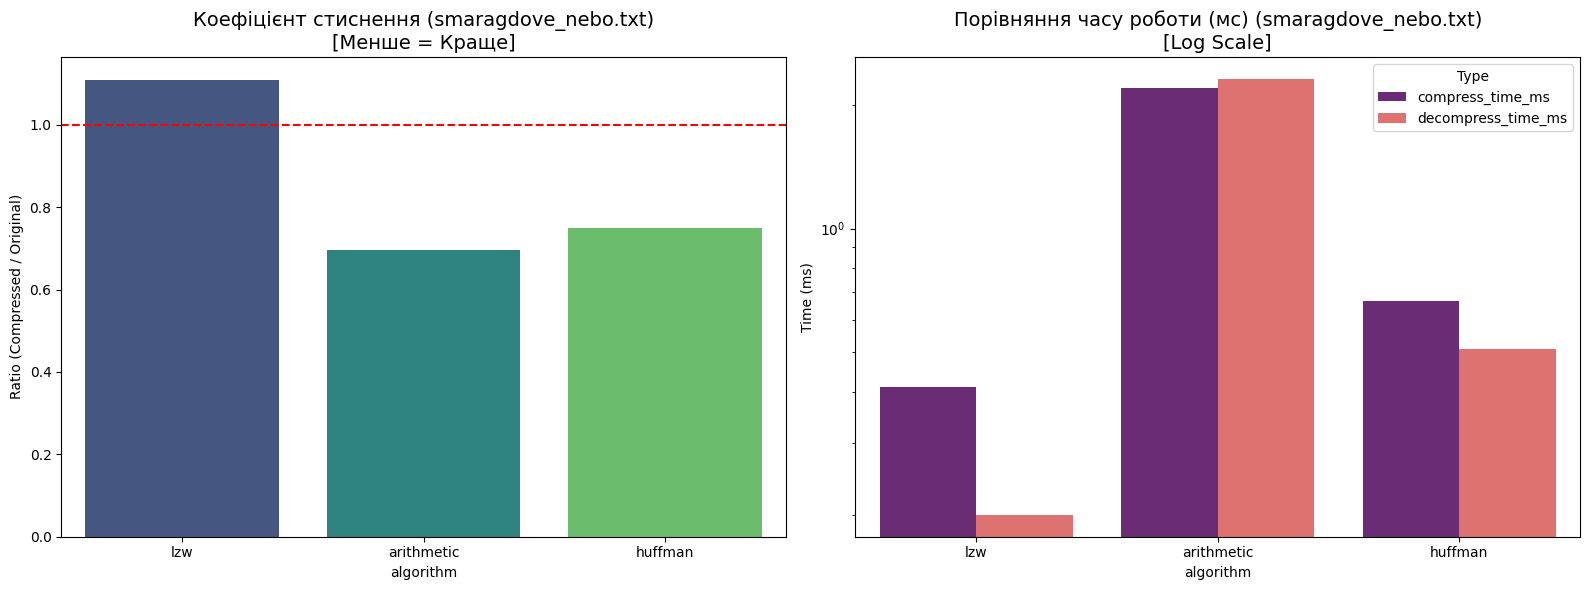

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,1.109091,0.410318,0.200510,True
1,arithmetic,0.695455,2.198458,2.316475,True
2,huffman,0.750000,0.665903,0.507593,True



>>> Аналіз файлу: tests_samples\franko.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 46,158 bytes
  Ratio: 0.401x
  Compress time: 56.51 ms
  Decompress time: 24.10 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 60,234 bytes
  Ratio: 0.523x
  Compress time: 771.75 ms
  Decompress time: 1036.71 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 115,090 -> 60,662 bytes
  Ratio: 0.527x
  Compress time: 133.57 ms
  Decompress time: 160.50 ms


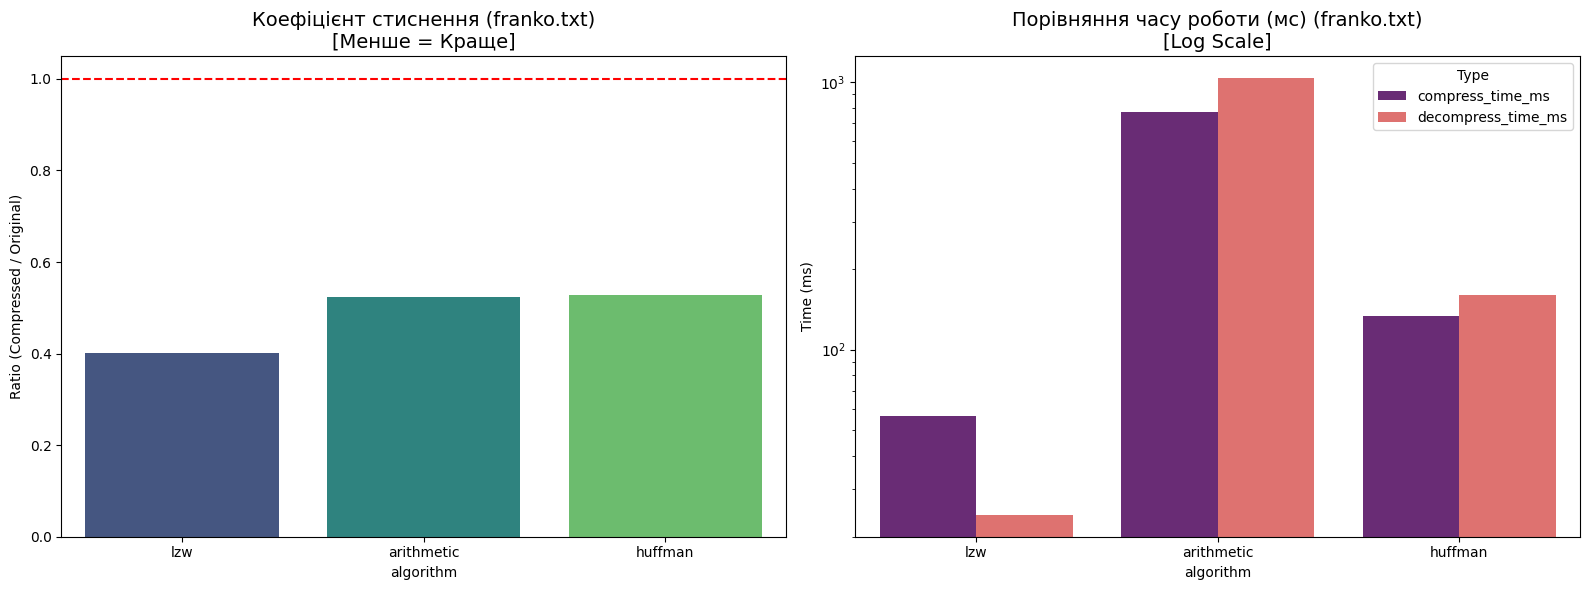

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.401060,56.507826,24.099588,True
1,arithmetic,0.523364,771.745920,1036.706924,True
2,huffman,0.527083,133.571386,160.504103,False



>>> Аналіз файлу: tests_samples\world.json

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 2,108,741 -> 735,928 bytes
  Ratio: 0.349x
  Compress time: 1400.11 ms
  Decompress time: 430.49 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,108,741 -> 1,057,807 bytes
  Ratio: 0.502x
  Compress time: 13680.39 ms
  Decompress time: 23315.78 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 2,108,741 -> 1,065,177 bytes
  Ratio: 0.505x
  Compress time: 3932.41 ms
  Decompress time: 4384.64 ms


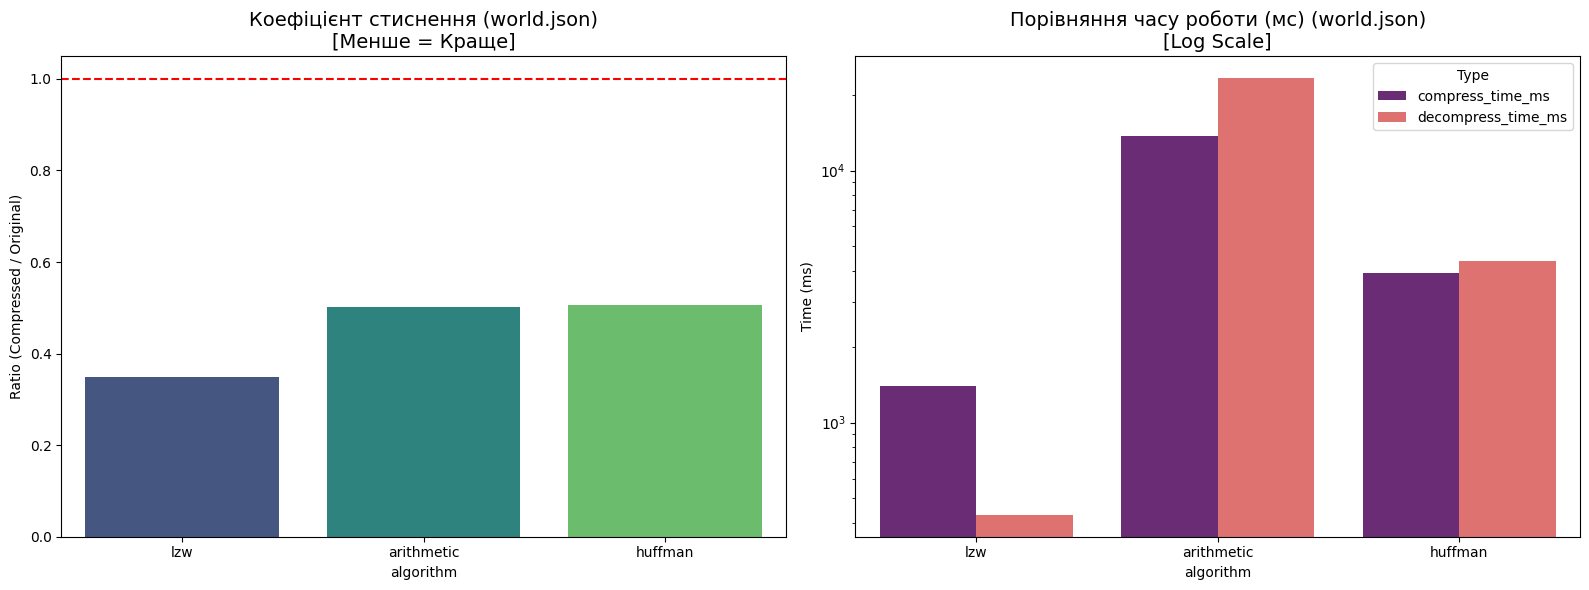

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.348989,1400.112152,430.485964,False
1,arithmetic,0.501630,13680.389643,23315.777540,True
2,huffman,0.505125,3932.414293,4384.644508,False



>>> Аналіз файлу: tests_samples\letters.csv

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 302 bytes
  Ratio: 0.296x
  Compress time: 0.87 ms
  Decompress time: 3.75 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 546 bytes
  Ratio: 0.535x
  Compress time: 26.49 ms
  Decompress time: 16.87 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 480 bytes
  Ratio: 0.471x
  Compress time: 1.68 ms
  Decompress time: 1.90 ms


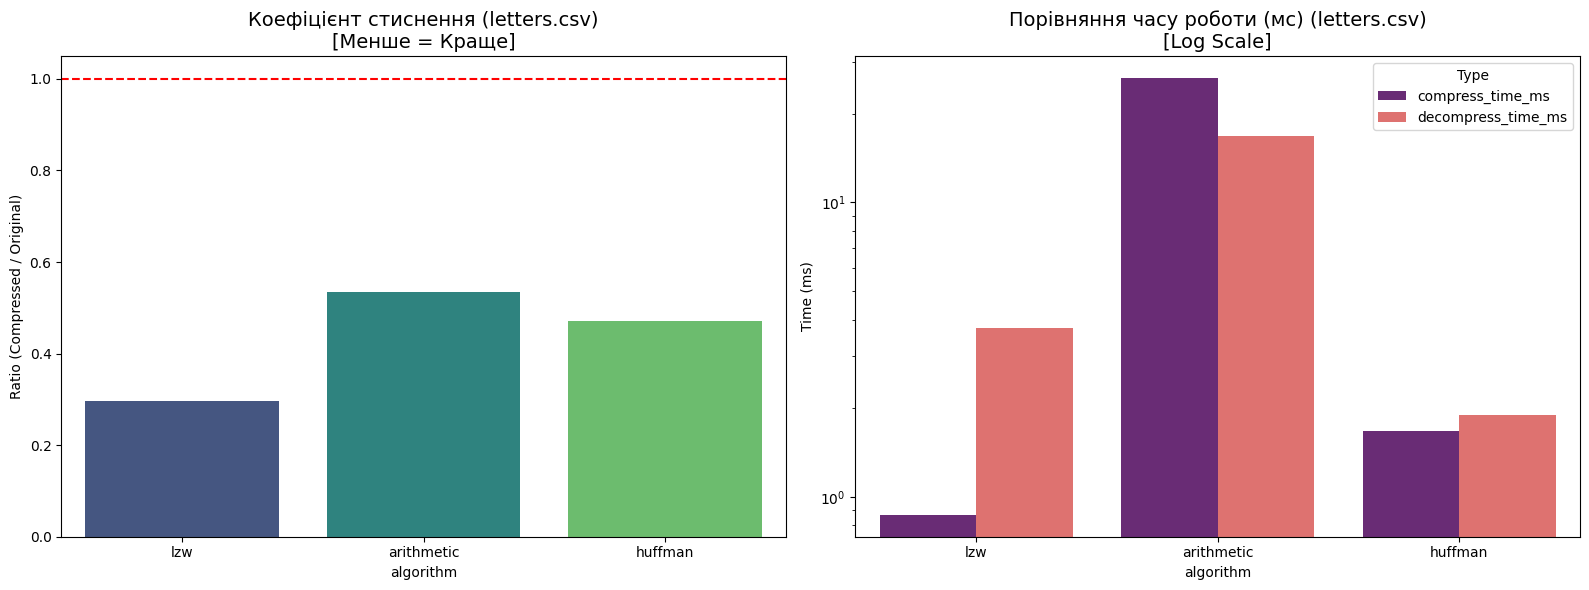

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.296078,0.868320,3.749132,True
1,arithmetic,0.535294,26.490211,16.868830,True
2,huffman,0.470588,1.679659,1.895905,True



>>> Аналіз файлу: tests_samples\iced_oatmilk_latte.jpg

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 60,445 -> 92,418 bytes
  Ratio: 1.529x
  Compress time: 126.74 ms
  Decompress time: 72.34 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 60,445 -> 60,358 bytes
  Ratio: 0.999x
  Compress time: 1142.27 ms
  Decompress time: 1374.46 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 60,445 -> 60,881 bytes
  Ratio: 1.007x
  Compress time: 186.76 ms
  Decompress time: 238.10 ms


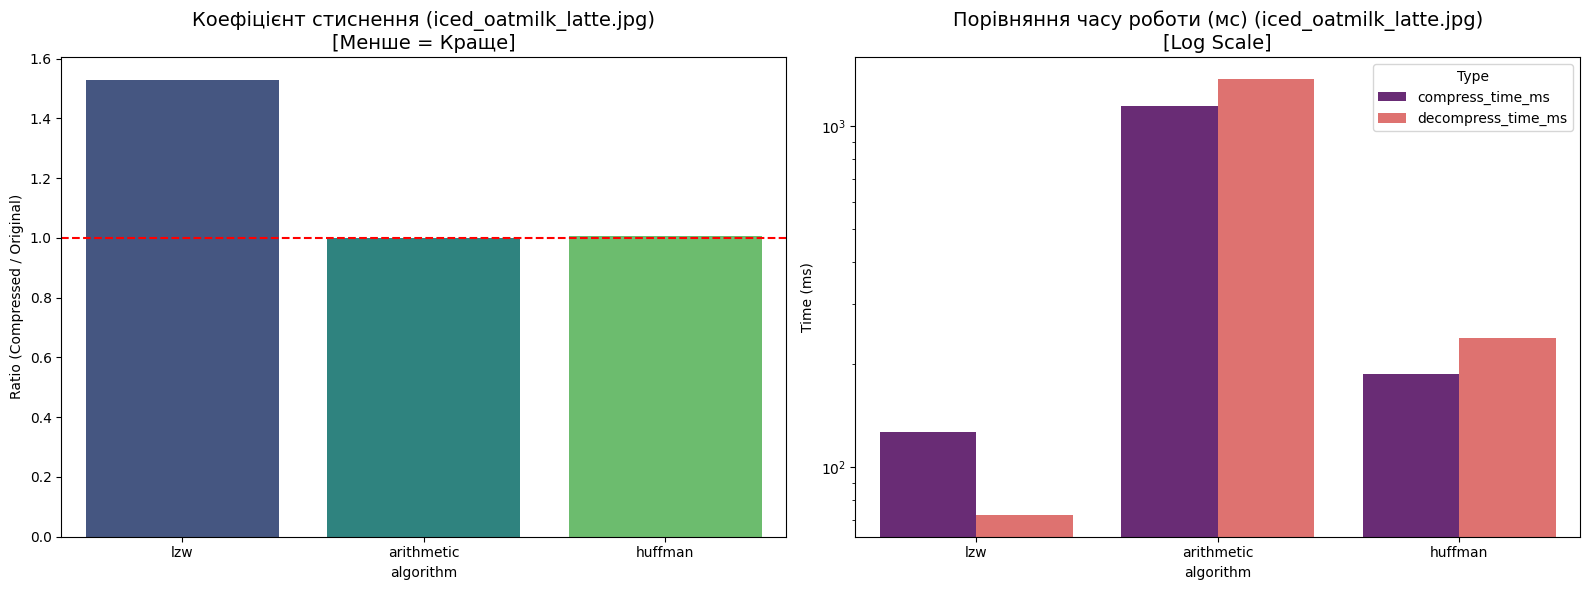

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,1.528960,126.744509,72.338343,True
1,arithmetic,0.998561,1142.271757,1374.456167,True
2,huffman,1.007213,186.763048,238.101244,True


Файл tests_samples\love_inst_instastiry.bmp не знайдено, пропускаємо.

>>> Аналіз файлу: tests_samples\sound.wav

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 3,678,286 -> 3,163,818 bytes
  Ratio: 0.860x
  Compress time: 5787.91 ms
  Decompress time: 3128.61 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,352,580 bytes
  Ratio: 0.911x
  Compress time: 45068.40 ms
  Decompress time: 52852.10 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,678,286 -> 3,362,231 bytes
  Ratio: 0.914x
  Compress time: 10452.20 ms
  Decompress time: 12516.37 ms


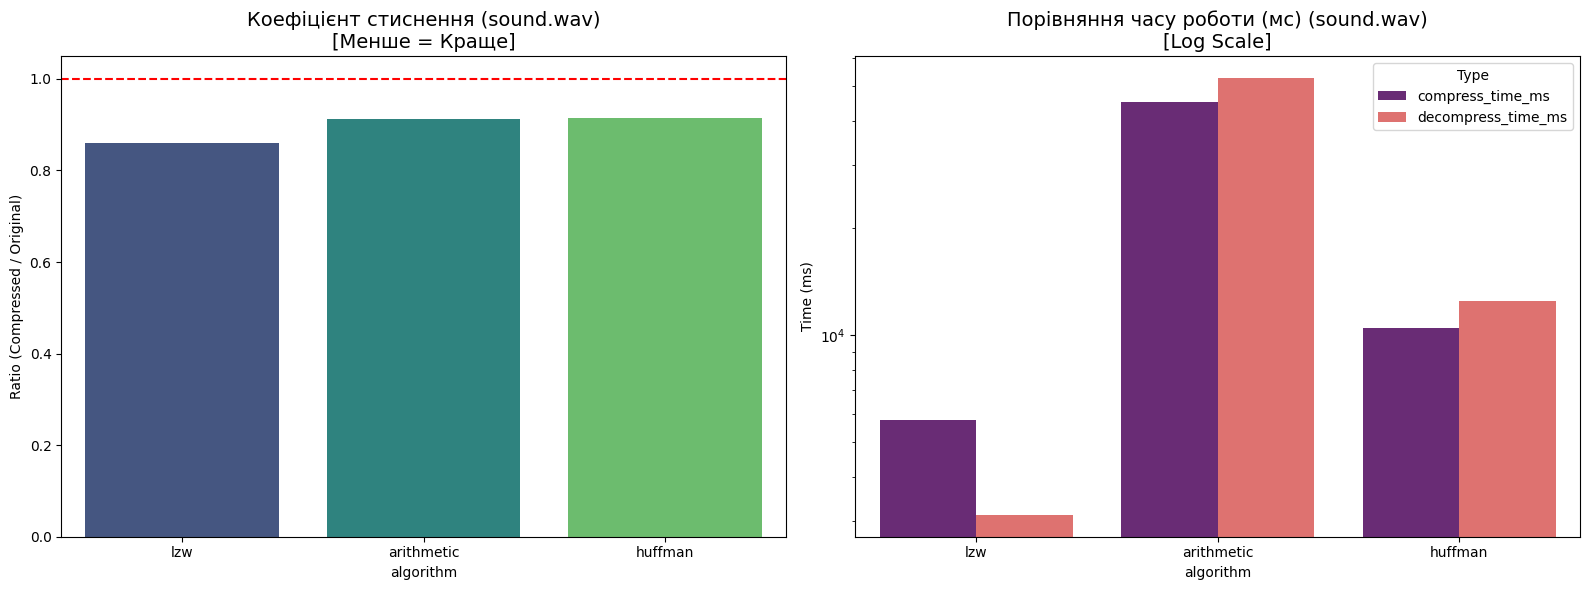

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.860134,5787.912607,3128.609180,False
1,arithmetic,0.911452,45068.395615,52852.097511,True
2,huffman,0.914075,10452.197075,12516.365290,True



>>> Аналіз файлу: tests_samples\CelineDion_MyHeartWillGoOn.flac

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 48,479,524 -> 40,137,374 bytes
  Ratio: 0.828x
  Compress time: 59325.00 ms
  Decompress time: 22455.59 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 48,479,524 -> 48,458,005 bytes
  Ratio: 1.000x
  Compress time: 458034.66 ms
  Decompress time: 637598.06 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 48,479,524 -> 48,480,042 bytes
  Ratio: 1.000x
  Compress time: 86240.52 ms
  Decompress time: 119336.75 ms


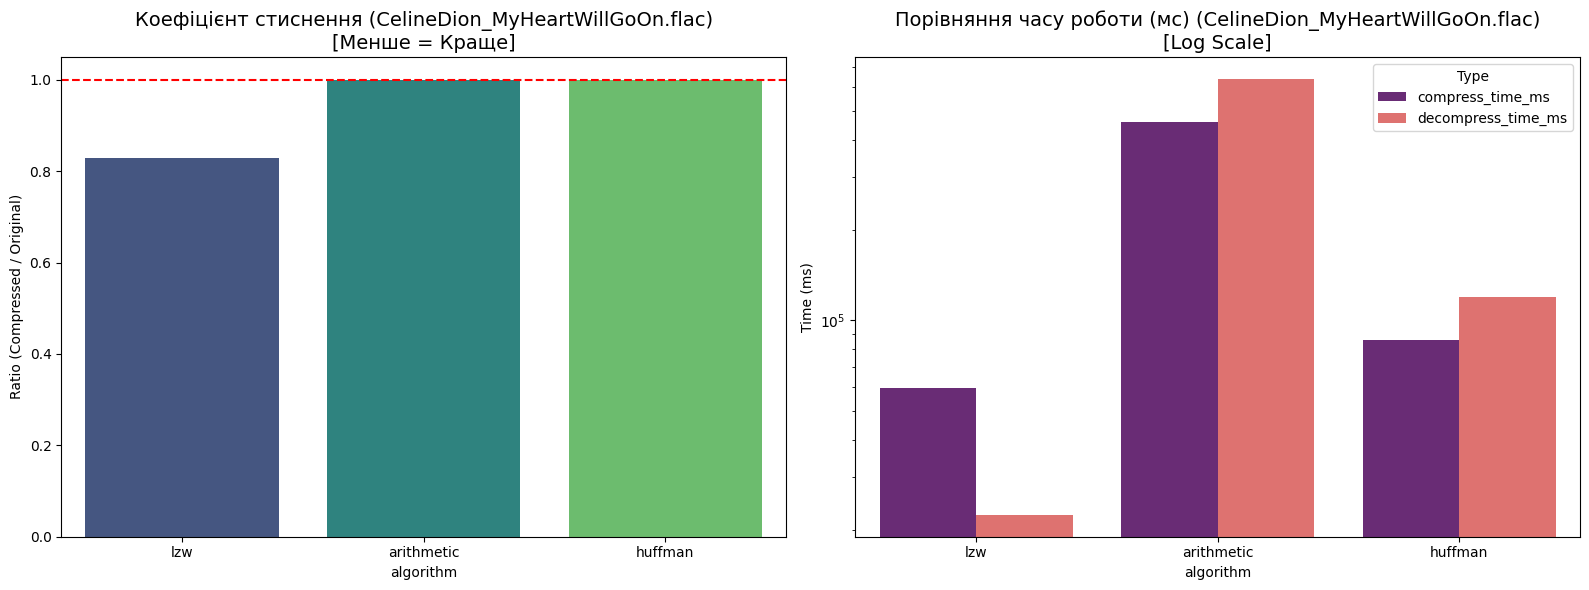

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.827924,59325.000286,22455.587626,False
1,arithmetic,0.999556,458034.663916,637598.058462,True
2,huffman,1.000011,86240.517855,119336.749315,True


In [ ]:
# Виклик аналізу для різних типів файлів
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "franko.txt"),
    os.path.join("tests_samples", "world.json"),
    os.path.join("tests_samples", "letters.csv"),
    os.path.join("tests_samples", "iced_oatmilk_latte.jpg"),
    os.path.join("tests_samples", "love_inst_instastiry.bmp"),
    os.path.join("tests_samples", "sound.wav"),
    os.path.join("tests_samples", "CelineDion_MyHeartWillGoOn.flac")
]

run_full_analysis(files_to_test)


>>> Аналіз файлу: tests_samples\kobzar.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 418,706 -> 144,072 bytes
  Ratio: 0.344x
  Compress time: 134.25 ms
  Decompress time: 45.50 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 418,706 -> 226,639 bytes
  Ratio: 0.541x
  Compress time: 1855.76 ms
  Decompress time: 2334.44 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 418,706 -> 227,843 bytes
  Ratio: 0.544x
  Compress time: 283.82 ms
  Decompress time: 314.90 ms


C:\Users\Даринка\AppData\Local\Temp\ipykernel_10416\2116217007.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Даринка\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


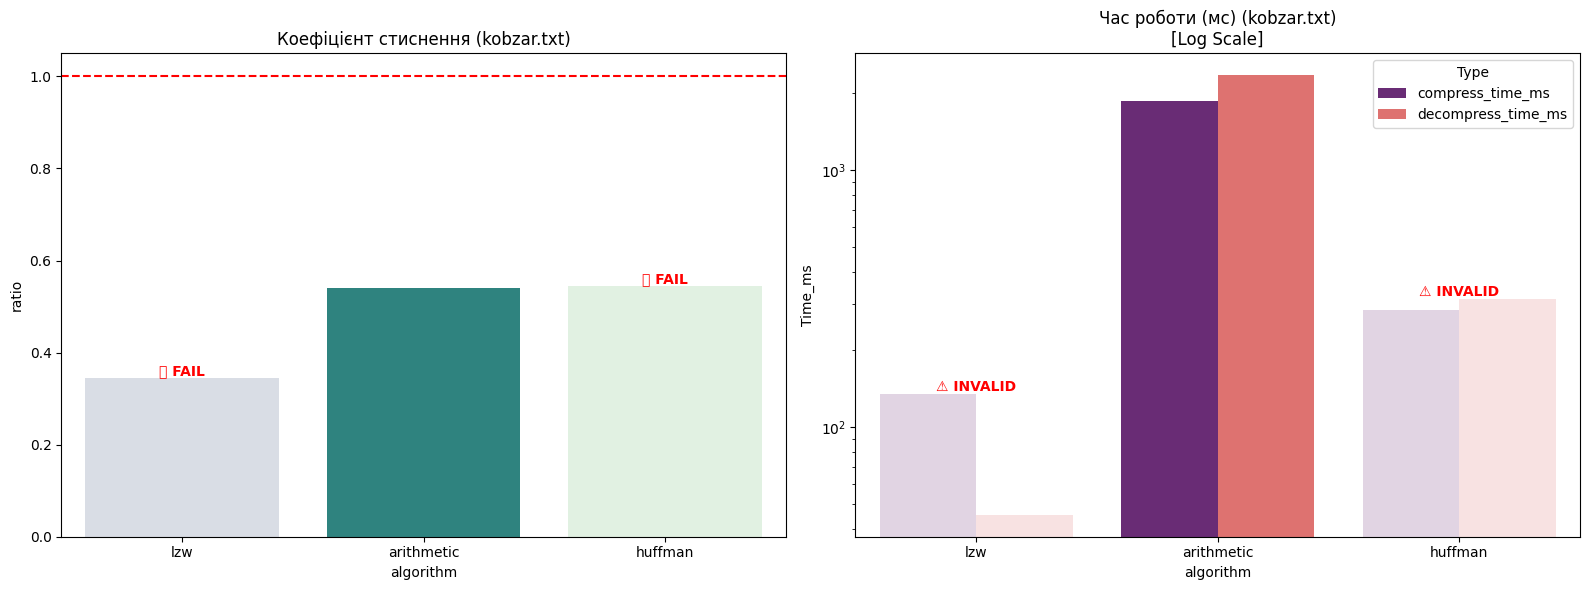

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.344089,134.253740,45.503139,False
1,arithmetic,0.541284,1855.759859,2334.435225,True
2,huffman,0.544160,283.822060,314.903259,False



>>> Аналіз файлу: tests_samples\Назар_проєкти.ogg

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 160,446 -> 210,772 bytes
  Ratio: 1.314x
  Compress time: 103.65 ms
  Decompress time: 70.36 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 160,446 -> 160,092 bytes
  Ratio: 0.998x
  Compress time: 932.33 ms
  Decompress time: 1174.08 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 160,446 -> 160,634 bytes
  Ratio: 1.001x
  Compress time: 168.09 ms
  Decompress time: 209.46 ms


C:\Users\Даринка\AppData\Local\Temp\ipykernel_10416\2116217007.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Даринка\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


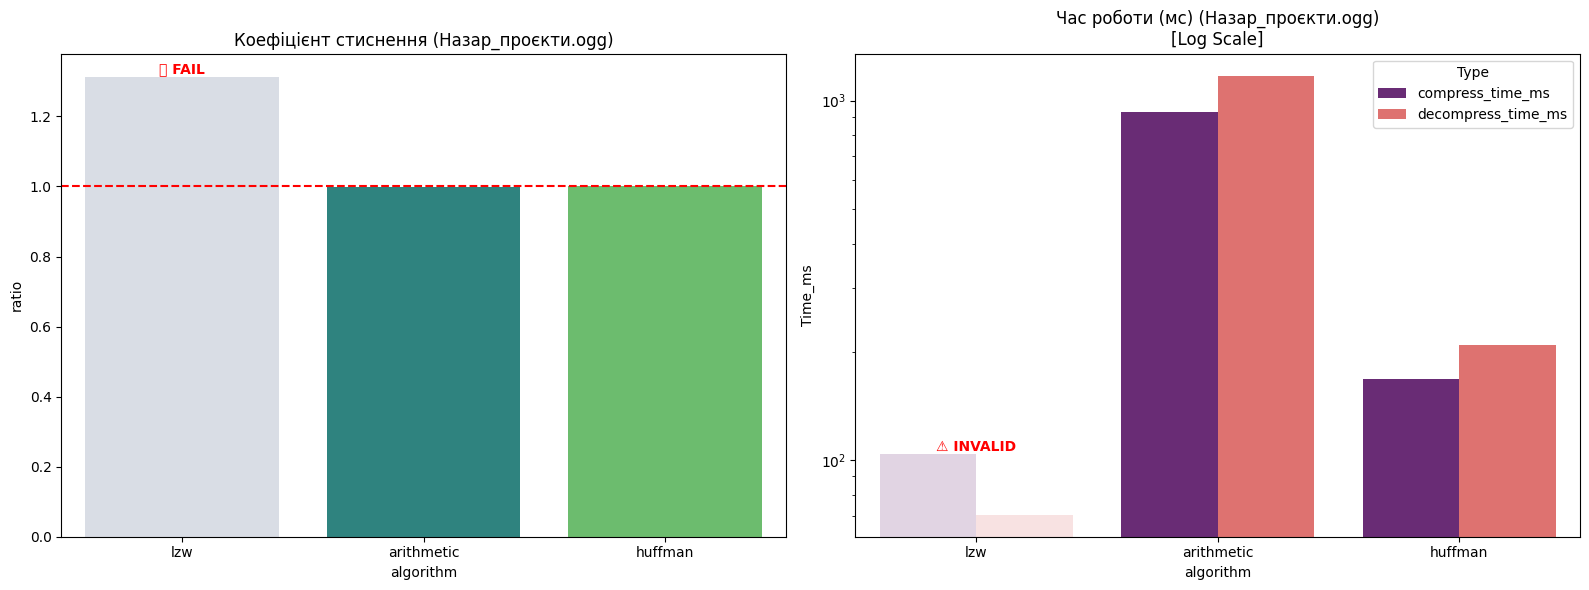

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,1.313663,103.652716,70.363283,False
1,arithmetic,0.997794,932.334185,1174.075127,True
2,huffman,1.001172,168.093681,209.458351,True



>>> Аналіз файлу: tests_samples\large_file.json

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 26,152,697 -> 3,953,100 bytes
  Ratio: 0.151x
  Compress time: 14314.50 ms
  Decompress time: 1570.91 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 26,152,697 -> 16,995,438 bytes
  Ratio: 0.650x
  Compress time: 151693.00 ms
  Decompress time: 212468.65 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 26,152,697 -> 17,101,151 bytes
  Ratio: 0.654x
  Compress time: 27362.97 ms
  Decompress time: 29303.06 ms


C:\Users\Даринка\AppData\Local\Temp\ipykernel_10416\2116217007.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Даринка\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


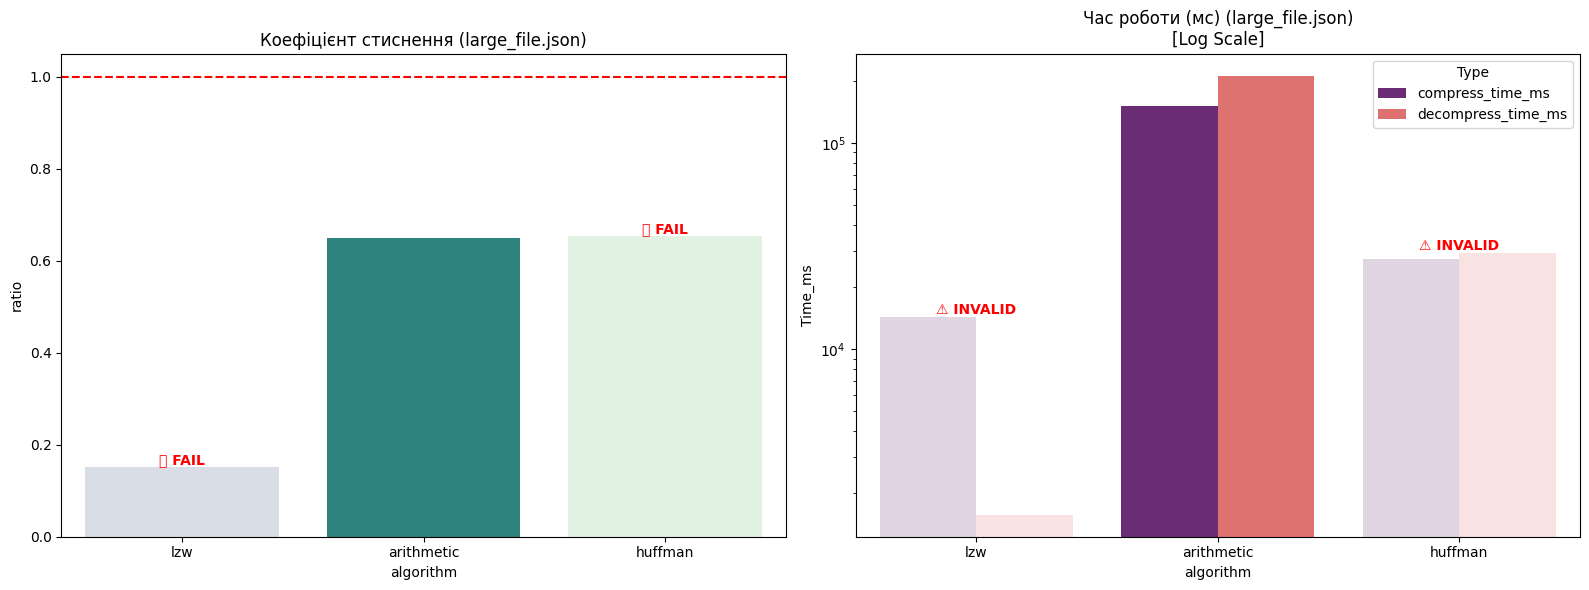

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.151155,14314.504385,1570.913553,False
1,arithmetic,0.649854,151693.004608,212468.653679,True
2,huffman,0.653896,27362.966061,29303.063154,False



>>> Аналіз файлу: tests_samples\smooth_operator.wav

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 2,695,482 -> 2,626,642 bytes
  Ratio: 0.974x
  Compress time: 2275.61 ms
  Decompress time: 1258.55 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,695,482 -> 2,610,871 bytes
  Ratio: 0.969x
  Compress time: 20340.74 ms
  Decompress time: 26015.93 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,695,482 -> 2,618,237 bytes
  Ratio: 0.971x
  Compress time: 3712.79 ms
  Decompress time: 6413.70 ms


C:\Users\Даринка\AppData\Local\Temp\ipykernel_10416\2116217007.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Даринка\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


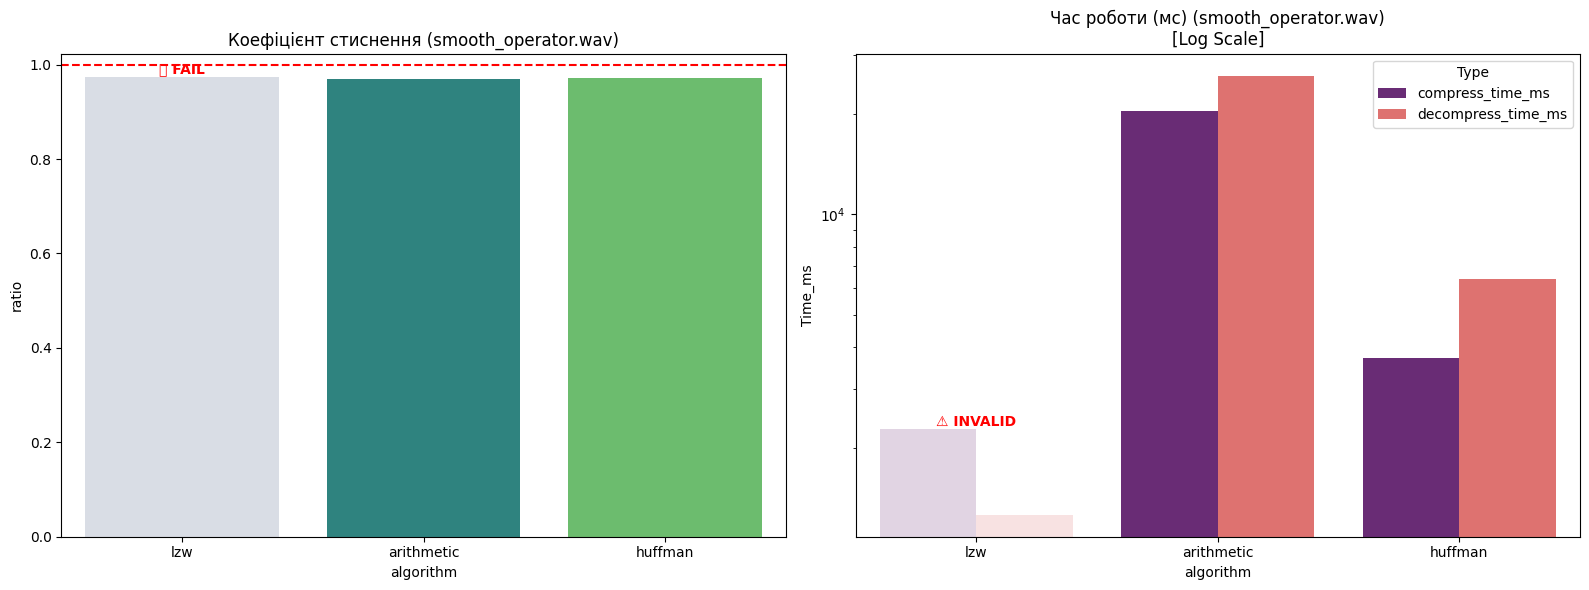

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.974461,2275.609493,1258.553505,False
1,arithmetic,0.968610,20340.739250,26015.927076,True
2,huffman,0.971343,3712.787628,6413.701773,True



>>> Аналіз файлу: tests_samples\parking_car.mp4

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 2,333,598 -> 2,211,260 bytes
  Ratio: 0.948x
  Compress time: 2980.16 ms
  Decompress time: 1760.73 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,333,598 -> 2,267,159 bytes
  Ratio: 0.972x
  Compress time: 27336.81 ms
  Decompress time: 30099.26 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,333,598 -> 2,275,810 bytes
  Ratio: 0.975x
  Compress time: 2445.01 ms
  Decompress time: 3115.13 ms


C:\Users\Даринка\AppData\Local\Temp\ipykernel_10416\2116217007.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Даринка\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


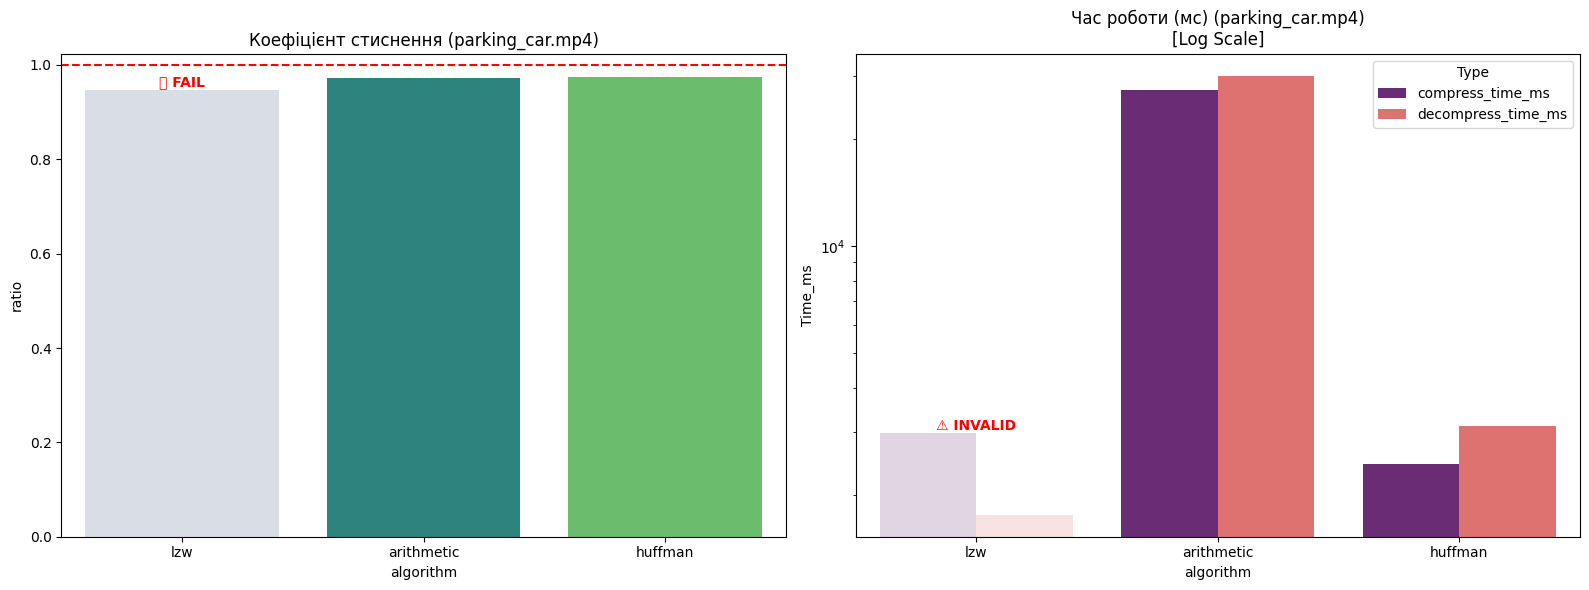

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.947575,2980.163336,1760.734081,False
1,arithmetic,0.971529,27336.806774,30099.259853,True
2,huffman,0.975237,2445.014000,3115.131855,True



>>> Аналіз файлу: tests_samples\Gemini_Generated_Image.png

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 1,757,570 -> 1,772,154 bytes
  Ratio: 1.008x
  Compress time: 1289.53 ms
  Decompress time: 737.23 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,757,570 -> 1,753,789 bytes
  Ratio: 0.998x
  Compress time: 12406.96 ms
  Decompress time: 14857.10 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,757,570 -> 1,757,582 bytes
  Ratio: 1.000x
  Compress time: 2415.94 ms
  Decompress time: 2880.38 ms


C:\Users\Даринка\AppData\Local\Temp\ipykernel_10416\2116217007.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Даринка\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


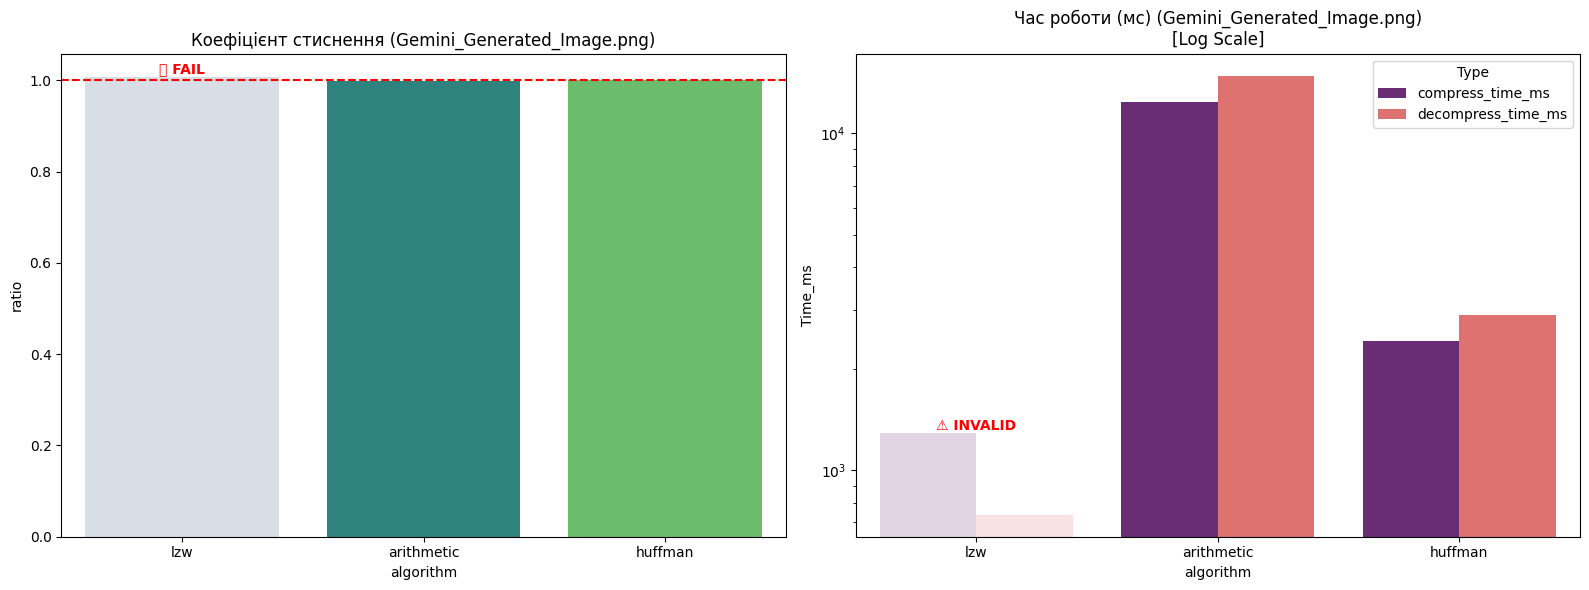

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,1.008298,1289.527178,737.232208,False
1,arithmetic,0.997849,12406.960726,14857.101202,True
2,huffman,1.000007,2415.944338,2880.384684,True



>>> Аналіз файлу: tests_samples\fast_reading.avi

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 3,779,794 -> 3,716,002 bytes
  Ratio: 0.983x
  Compress time: 3042.58 ms
  Decompress time: 1636.93 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,779,794 -> 3,776,774 bytes
  Ratio: 0.999x
  Compress time: 27726.02 ms
  Decompress time: 31936.27 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 3,779,794 -> 3,778,655 bytes
  Ratio: 1.000x
  Compress time: 4927.35 ms
  Decompress time: 6087.93 ms


C:\Users\Даринка\AppData\Local\Temp\ipykernel_10416\2116217007.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Даринка\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


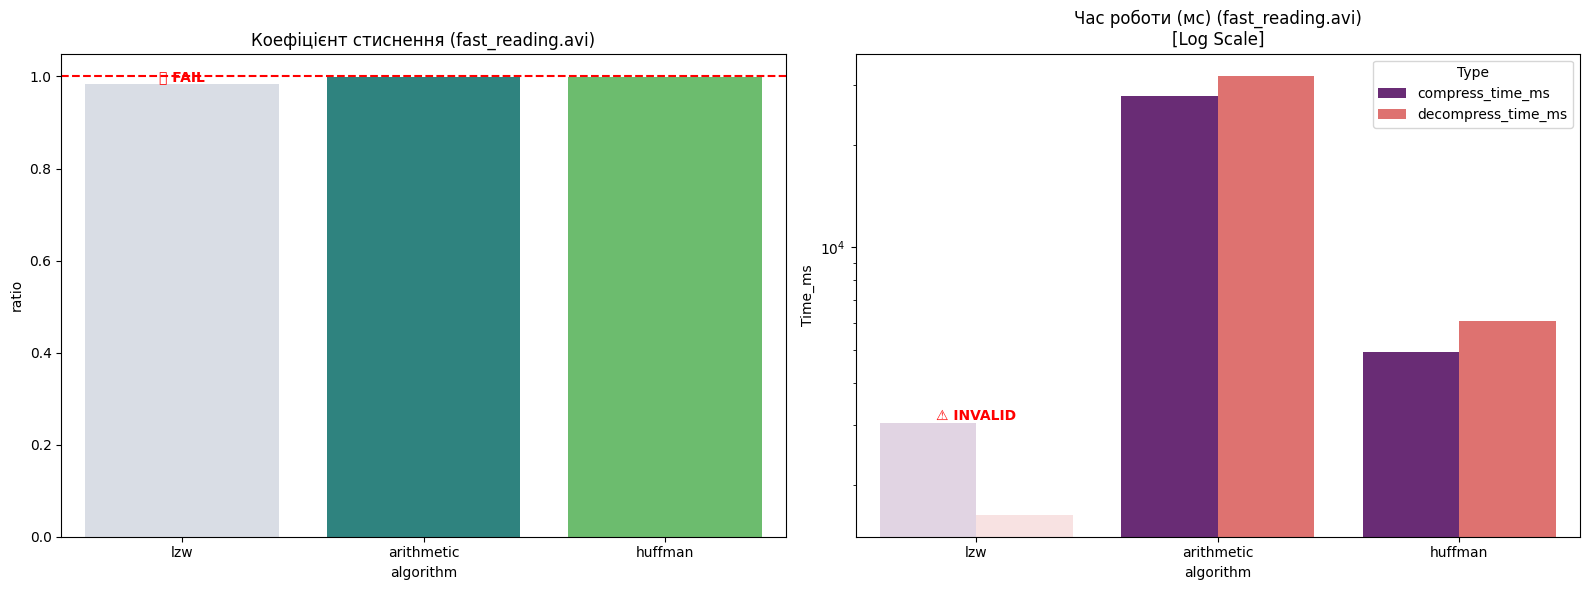

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.983123,3042.577267,1636.930466,False
1,arithmetic,0.999201,27726.023674,31936.272383,True
2,huffman,0.999699,4927.346230,6087.926626,True


In [5]:
def visualize_results(df, title_suffix=""):
    if df.empty: return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(x='algorithm', y='ratio', data=df, ax=axes[0],
                palette='viridis', hue='algorithm', legend=False)
    axes[0].set_title(f'Коефіцієнт стиснення {title_suffix}')
    axes[0].axhline(1, color='red', linestyle='--')

    df_time = df.melt(id_vars=['algorithm', 'is_valid'],
                      value_vars=['compress_time_ms', 'decompress_time_ms'],
                      var_name='Type', value_name='Time_ms')

    sns.barplot(x='algorithm', y='Time_ms', hue='Type', data=df_time,
                ax=axes[1], palette='magma')
    axes[1].set_title(f'Час роботи (мс) {title_suffix}\n[Log Scale]')
    axes[1].set_yscale('log')

    for i, algo_name in enumerate(df['algorithm']):
        row = df[df['algorithm'] == algo_name].iloc[0]

        if not row['is_valid']:
            y_ratio = row['ratio']
            axes[0].text(i, y_ratio, '⚠️ FAIL', ha='center', va='bottom',
                         color='red', fontweight='bold')

            y_time = max(row['compress_time_ms'], row['decompress_time_ms'])
            axes[1].text(i, y_time, '⚠️ FAIL', ha='center', va='bottom',
                         color='red', fontweight='bold')

            for ax in axes:
                for bar in ax.patches:
                    if hasattr(bar, 'get_x') and abs(bar.get_x() + bar.get_width()/2 - i) < 0.3:
                        bar.set_alpha(0.2)

    plt.tight_layout()
    plt.show()

files_to_test = [
    os.path.join("tests_samples", "kobzar.txt"),
    os.path.join("tests_samples", "Назар_проєкти.ogg"),
    os.path.join("tests_samples", "large_file.json"),
    os.path.join("tests_samples", "smooth_operator.wav"),
    os.path.join("tests_samples", "parking_car.mp4"),
    os.path.join("tests_samples", "Gemini_Generated_Image.png"),
    os.path.join("tests_samples", "fast_reading.avi")
]

run_full_analysis(files_to_test)

In [6]:
def visualize_results(df, title_suffix=""):
    if df.empty: return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(x='algorithm', y='ratio', data=df, ax=axes[0],
                palette='viridis', hue='algorithm', legend=False)
    axes[0].set_title(f'Коефіцієнт стиснення {title_suffix}')
    axes[0].axhline(1, color='red', linestyle='--')

    y_min = df['ratio'].min()
    y_max = df['ratio'].max()


    margin = (y_max - y_min) * 0.1 if y_max != y_min else 0.05
    axes[0].set_ylim(y_min - margin, y_max + margin)

    df_time = df.melt(id_vars=['algorithm', 'is_valid'],
                      value_vars=['compress_time_ms', 'decompress_time_ms'],
                      var_name='Type', value_name='Time_ms')

    sns.barplot(x='algorithm', y='Time_ms', hue='Type', data=df_time,
                ax=axes[1], palette='magma')
    axes[1].set_title(f'Час роботи (мс) {title_suffix}\n[Log Scale]')
    axes[1].set_yscale('log')

    for i, algo_name in enumerate(df['algorithm']):
        row = df[df['algorithm'] == algo_name].iloc[0]

        if not row['is_valid']:
            y_ratio = row['ratio']
            axes[0].text(i, y_ratio, '⚠️ FAIL', ha='center', va='bottom',
                         color='red', fontweight='bold')

            y_time = max(row['compress_time_ms'], row['decompress_time_ms'])
            axes[1].text(i, y_time, '⚠️ FAIL', ha='center', va='bottom',
                         color='red', fontweight='bold')


            for ax in axes:
                for patch in ax.patches:
                    if abs(patch.get_x() + patch.get_width()/2 - i) < 0.4:
                        patch.set_alpha(0.2)

    plt.tight_layout()
    plt.show()


>>> Аналіз файлу: tests_samples\smaragdove_nebo.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 244 bytes
  Ratio: 1.109x
  Compress time: 0.19 ms
  Decompress time: 0.15 ms

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 248 bytes
  Ratio: 1.127x
  Compress time: 1.13 ms
  Decompress time: 0.13 ms

TESTING BWT
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 138 bytes
  Ratio: 0.627x
  Compress time: 0.19 ms
  Decompress time: 13.36 ms

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 440 bytes
  Ratio: 2.000x
  Compress time: 0.07 ms
  Decompress time: 0.12 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 220 -> 153 bytes
  Ratio: 0.695x
  Compress time: 1.32 ms
  Decompress time: 1.64 ms

TESTING DEFLATE
------

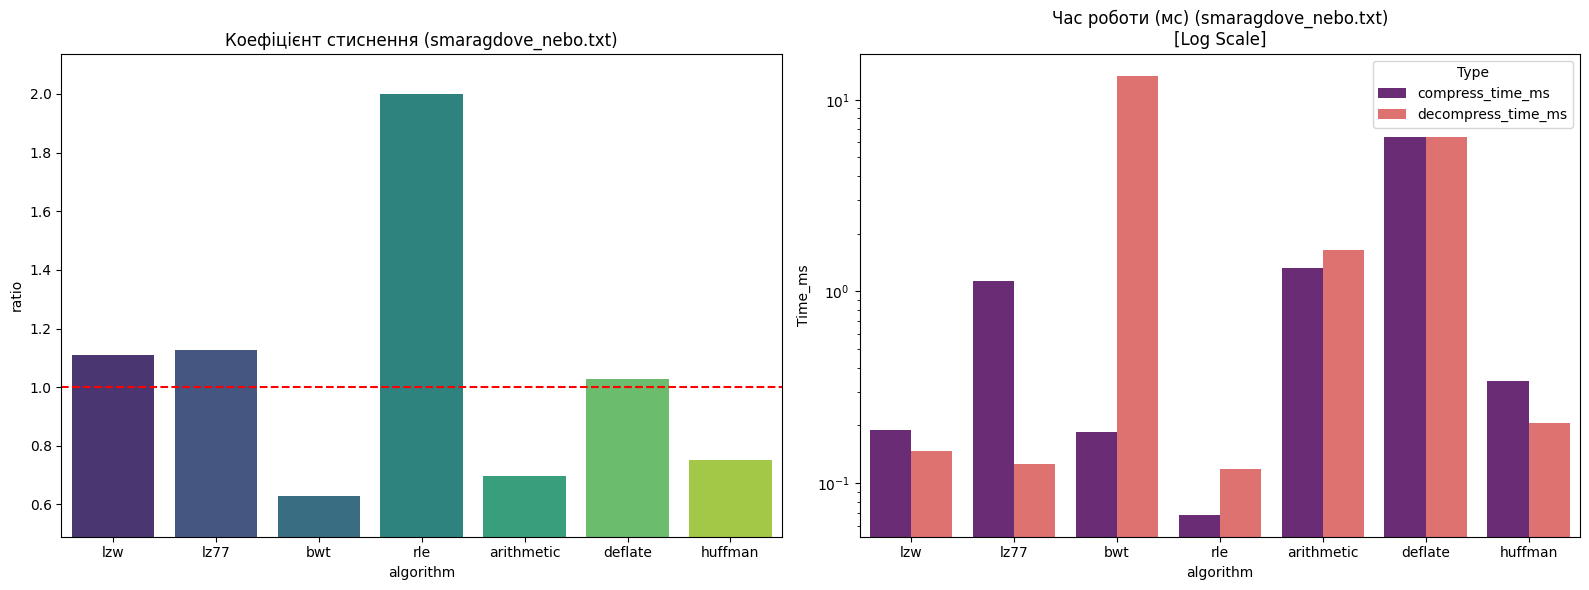

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,1.109091,0.190020,0.147820,True
1,lz77,1.127273,1.132011,0.125170,True
2,bwt,0.627273,0.185728,13.357878,True
3,rle,2.000000,0.068426,0.118017,True
4,arithmetic,0.695455,1.322746,1.636982,True
5,deflate,1.027273,6.409883,6.380796,True
6,huffman,0.750000,0.339508,0.206947,True



>>> Аналіз файлу: tests_samples\letters.csv

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 302 bytes
  Ratio: 0.296x
  Compress time: 0.43 ms
  Decompress time: 0.18 ms

TESTING LZ77
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 110 bytes
  Ratio: 0.108x
  Compress time: 4.38 ms
  Decompress time: 0.13 ms

TESTING BWT
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 66 bytes
  Ratio: 0.065x
  Compress time: 0.96 ms
  Decompress time: 229.54 ms

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 60 bytes
  Ratio: 0.059x
  Compress time: 0.11 ms
  Decompress time: 0.04 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 1,020 -> 546 bytes
  Ratio: 0.535x
  Compress time: 4.56 ms
  Decompress time: 5.38 ms

TESTING DEFLATE
-----

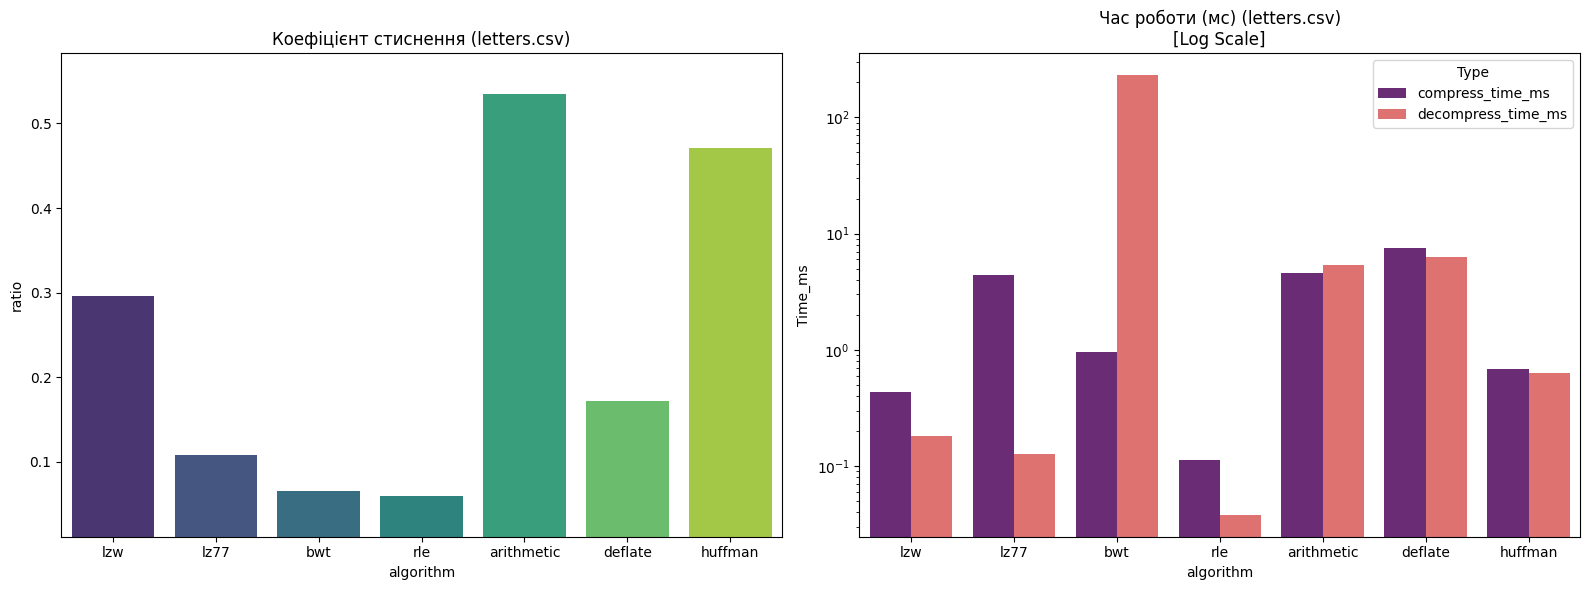

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.296078,0.431061,0.181437,True
1,lz77,0.107843,4.384279,0.128031,True
2,bwt,0.064706,0.960827,229.540825,True
3,rle,0.058824,0.111818,0.038147,True
4,arithmetic,0.535294,4.555702,5.382061,True
5,deflate,0.171569,7.575750,6.300449,True
6,huffman,0.470588,0.681162,0.634193,True


In [10]:
algorithms = ['lzw', 'lz77', 'bwt', 'rle', 'arithmetic', 'deflate', 'huffman']
files_to_test = [
    os.path.join("tests_samples", "smaragdove_nebo.txt"),
    os.path.join("tests_samples", "letters.csv"),
]

run_full_analysis(files_to_test, algorithms)


ще можна додати щоб якось позначалося який алгоритм в кожному графіку найшвидший/найефевтипінший


>>> Аналіз файлу: tests_samples\the_life_of_dickens.txt

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 2,671,895 -> 896,152 bytes
  Ratio: 0.335x
  Compress time: 1337.59 ms
  Decompress time: 378.57 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 2,671,895 -> 1,522,508 bytes
  Ratio: 0.570x
  Compress time: 11135.86 ms
  Decompress time: 14231.66 ms

TESTING HUFFMAN
--------------------------------------------------

RESULTS:
  Correct: FAIL
  Size: 2,671,895 -> 1,536,301 bytes
  Ratio: 0.575x
  Compress time: 1867.56 ms
  Decompress time: 2116.57 ms


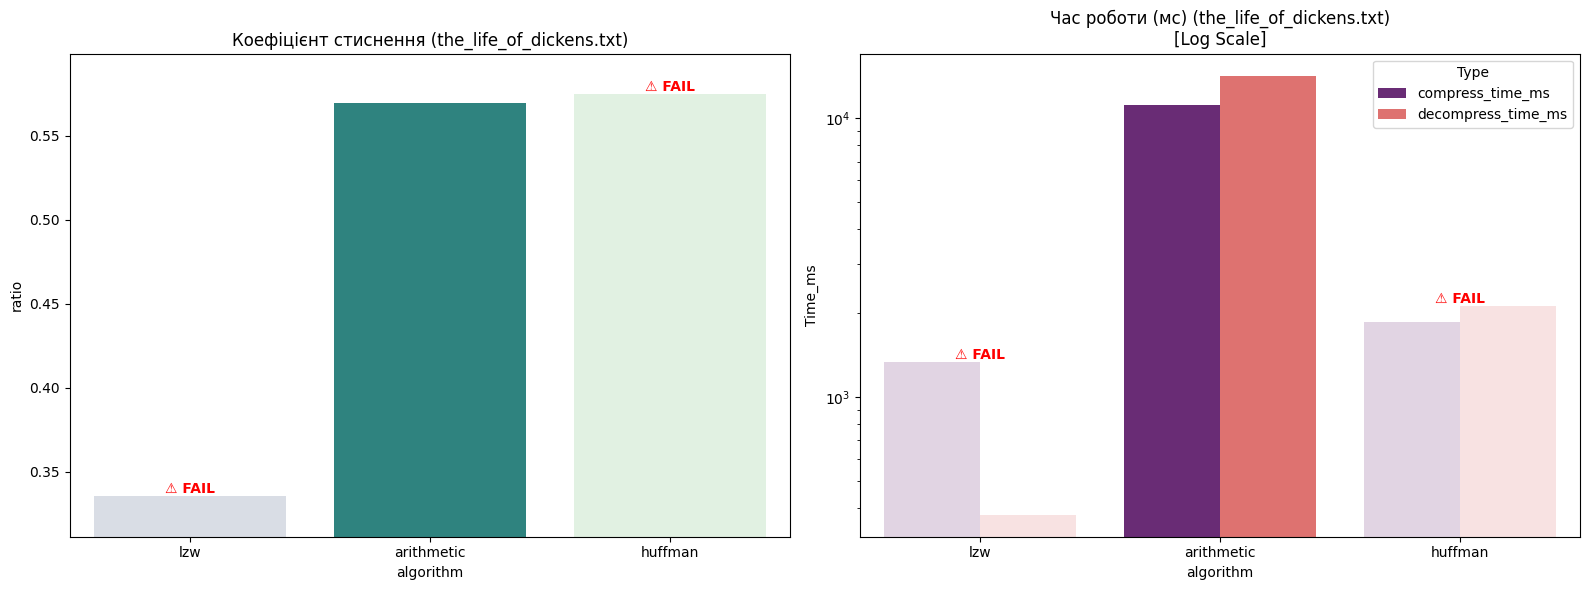

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,lzw,0.335399,1337.586403,378.565311,False
1,arithmetic,0.569823,11135.859013,14231.661081,True
2,huffman,0.574986,1867.563725,2116.572618,False


In [13]:
algorithms = ['lzw', 'arithmetic', 'huffman']
files_to_test = [
    os.path.join("tests_samples", "the_life_of_dickens.txt")
    ]

run_full_analysis(files_to_test, algorithms)
